# Predicting ETA Uncertainty: Late Delivery Risk Classification

## Problem & decision context

**Business question:**  
Can we predict the probability that an order will arrive *later than the promised ETA range*?

Instead of predicting delivery time itself, we model whether the **actual delivery time exceeds the upper ETA bound**.

**Why this matters:**

- Customers care a lot about **ETA reliability**, not just speed.
- Repeatedly missing the upper bound hurts **trust**, **NPS**, and **retention**.
- Having a robust late-risk model allows Wolt to:
  - Adjust ETA ranges dynamically for high-risk orders.
  - Trigger proactive communication (“your order may be delayed”).
  - Support operational decisions (prioritization, batching rules, supply management).

**Prediction target:**

\[
\text{late} = \mathbb{1}\{\text{actual\_delivery\_time} > \text{estimated\_upper\_minutes}\}
\]

The model outputs \( P(\text{late} = 1 \mid \text{features}) \).

In [59]:
# Imports

import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, brier_score_loss, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import calibration_curve

import matplotlib.pyplot as plt

In [60]:
# 2. Loading the data

path = "orders_spring_2022.csv"
df = pd.read_csv(path)

df.head()

,order_placed_at_utc,order_category,item_count,actual_delivery_time_minutes,estimated_delivery_time_lower_minutes,estimated_delivery_time_upper_minutes,venue_location_h3_index,customer_location_h3_index,courier_supply_index,precipitation
0,2022-02-01T06:01:00.000000,Retail,9,23.373547,15.0,25.0,881126d307fffff,881126d307fffff,1.48,0.0
1,2022-02-01T06:16:00.000000,Food delivery,2,72.864126,40.0,50.0,881126d339fffff,881126d311fffff,1.49,0.0
2,2022-02-01T06:46:00.000000,Food delivery,3,48.737269,30.0,40.0,881126d33dfffff,881126d331fffff,1.50,0.0
3,2022-02-01T07:17:00.000000,Food delivery,5,37.744732,35.0,45.0,881126d331fffff,881126d337fffff,1.56,0.0
4,2022-02-01T07:21:00.000000,Retail,15,68.881136,35.0,45.0,881126d06bfffff,881126d027fffff,1.58,0.0


## Basic EDA & target construction

We:

1. Parse the order timestamp.
2. Create a **binary target**: `late = 1` if actual delivery time > upper ETA bound.
3. Check the overall late rate and basic sanity of key fields.


In [61]:
# Timestamp + target

df["ts"] = pd.to_datetime(df["order_placed_at_utc"])

df["late"] = (
    df["actual_delivery_time_minutes"]
    > df["estimated_delivery_time_upper_minutes"]
).astype(int)

df["late"].mean()

np.float64(0.35406142250020045)

### Time-based patterns

We extract simple calendar features relevant for operations:

- `hour`: hour of day when the order was placed
- `dow`: day of week (0 = Monday)
- `is_weekend`: weekend indicator

These often correlate with demand surges, congestion, and thus ETA risk.

In [62]:
df["hour"] = df["ts"].dt.hour
df["dow"] = df["ts"].dt.dayofweek
df["wknd"] = df["dow"].isin([5, 6]).astype(int)

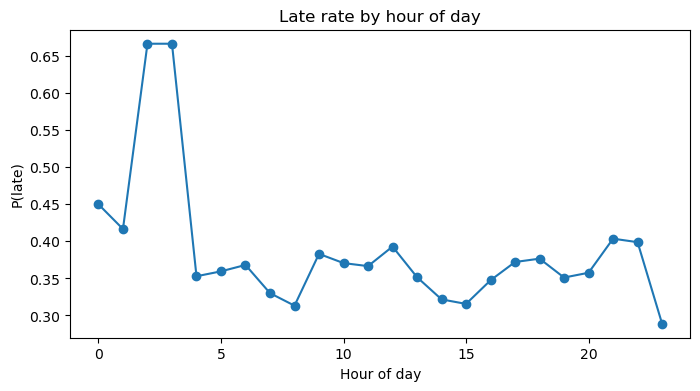

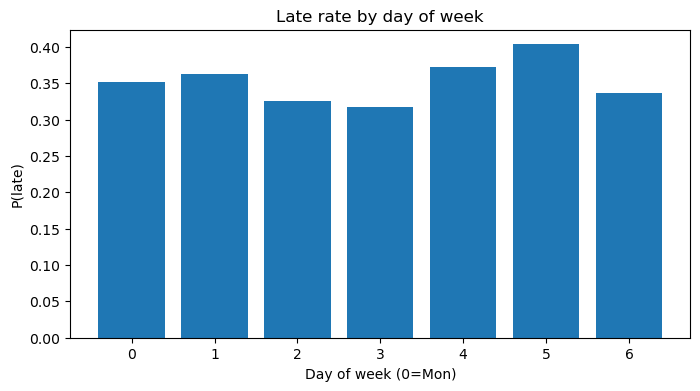

In [63]:
# Late rate by hour of day
late_by_hr = df.groupby("hour")["late"].mean()

plt.figure(figsize=(8, 4))
plt.plot(late_by_hr.index, late_by_hr.values, marker="o")
plt.xlabel("Hour of day")
plt.ylabel("P(late)")
plt.title("Late rate by hour of day")
plt.show()


# Late rate by day of week
late_by_dow = df.groupby("dow")["late"].mean()

plt.figure(figsize=(8, 4))
plt.bar(late_by_dow.index, late_by_dow.values)
plt.xlabel("Day of week (0=Mon)")
plt.ylabel("P(late)")
plt.title("Late rate by day of week")
plt.show()

### Geospatial simplification

We have `venue_location_h3_index` and `customer_location_h3_index` as H3 indexes.

For a simple first version, instead of computing full H3 distances, we create:

- `same_h3_cell`: 1 if venue and customer share the same index, 0 otherwise  
  (approx. very local deliveries)
- A **coarse area id**: first few characters of the venue H3 index, as a region proxy.

This keeps the model simple and scalable.


In [64]:
df["same_h3"] = (
    df["venue_location_h3_index"]
    == df["customer_location_h3_index"]
).astype(int)

df["venue_reg"] = df["venue_location_h3_index"].str.slice(0, 5)

## Feature set

We focus on:

**Numerical features**
- `item_count`
- `courier_supply_index`
- `precipitation`
- `estimated_delivery_time_lower_minutes`
- `estimated_delivery_time_upper_minutes`
- `hour`
- `dow`
- `is_weekend`
- `same_h3`

**Categorical features**
- `order_category`
- `venue_region`

Intentionally **not** using:
- Exact H3 index as high-cardinality categories (would overfit / heavy).
- Raw timestamp (we use hour/dow instead).
- Direct “actual delivery time” (it would leak the label).

This keeps the model reasonable for production and easier to monitor.

In [65]:
# Feature lists

num_f = [
    "item_count",
    "courier_supply_index",
    "precipitation",
    "estimated_delivery_time_lower_minutes",
    "estimated_delivery_time_upper_minutes",
    "hour",
    "dow",
    "wknd",
    "same_h3",
]

cat_f = [
    "order_category",
    "venue_reg",
]

X = df[num_f + cat_f]
y = df["late"]

## Train / test split (time-based)

To mimic production, we do a **chronological split**:

- Train on earlier orders.
- Test on later orders.

This prevents future information from leaking into the past.

In [66]:
# Time-based split

df = df.sort_values("ts").reset_index(drop=True)
cut = int(len(df) * 0.8)

tr = df.iloc[:cut]
te = df.iloc[cut:]

X_tr = tr[num_f + cat_f]
y_tr = tr["late"]

X_te = te[num_f + cat_f]
y_te = te["late"]

In [67]:
# Preprocessing

prep = ColumnTransformer(
    [
        ("num", "passthrough", num_f),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_f),
    ]
)

## Baseline model: Logistic Regression

Logistic regression is:

- Fast
- Interpretable
- Easy to calibrate

Good baseline for probability outputs used in a product context.

In [68]:
df[num_f + cat_f].isna().sum()

item_count                                 0
courier_supply_index                      98
precipitation                            870
estimated_delivery_time_lower_minutes     56
estimated_delivery_time_upper_minutes     56
hour                                       0
dow                                        0
wknd                                       0
same_h3                                    0
order_category                             0
venue_reg                                  0
dtype: int64

In [69]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
])

prep = ColumnTransformer(
    [
        ("num", num_pipe, num_f),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_f),
    ]
)

In [70]:
# Logistic regression baseline

logm = Pipeline(
    [
        ("prep", prep),
        ("clf", LogisticRegression(max_iter=1000))
    ]
)

logm.fit(X_tr, y_tr)

p_log = logm.predict_proba(X_te)[:, 1]

print("Log AUC:", roc_auc_score(y_te, p_log))
print("Log PR-AUC:", average_precision_score(y_te, p_log))
print("Log Brier:", brier_score_loss(y_te, p_log))

Log AUC: 0.6326152091952447
Log PR-AUC: 0.5006288312091496
Log Brier: 0.2151775805785602


In [71]:
#sanity check
p_log[:5]

array([0.56571105, 0.49744011, 0.59125949, 0.47025834, 0.51033886])

## Non-linear model: HistGradientBoostingClassifier

We also try a tree-based model to capture interactions and non-linearities, still staying efficient and production-friendly.

In [72]:
gbm = Pipeline(
    [
        ("prep", prep),
        ("clf", HistGradientBoostingClassifier(random_state=42))
    ]
)

gbm.fit(X_tr, y_tr)

p_gbm = gbm.predict_proba(X_te)[:, 1]

print("GBM AUC:", roc_auc_score(y_te, p_gbm))
print("GBM PR-AUC:", average_precision_score(y_te, p_gbm))
print("GBM Brier:", brier_score_loss(y_te, p_gbm))

GBM AUC: 0.6430964801707276
GBM PR-AUC: 0.5062081897121977
GBM Brier: 0.21054559764416556


## Calibration & thresholds

For a product setting where we expose **risk of being late**, well-calibrated probabilities are important.

We:

- Plot calibration curves.
- Inspect performance at a decision threshold (e.g. 0.3) that could be used to trigger a “high delay risk” label.

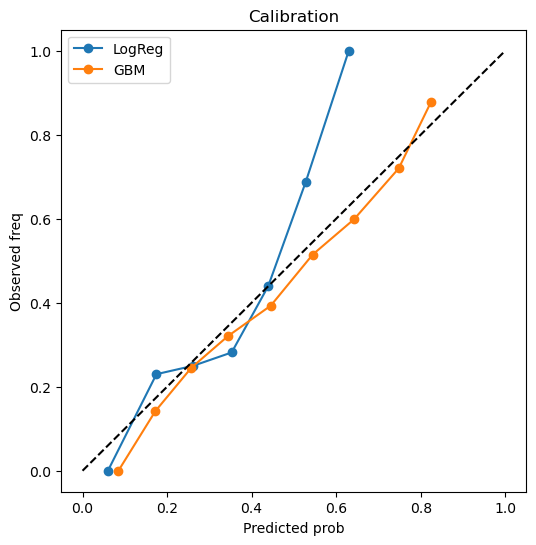

In [73]:
# Calibration plot

def cal_plot(y, p, name):
    f, m = calibration_curve(y, p, n_bins=10)
    plt.plot(m, f, marker="o", label=name)

plt.figure(figsize=(6, 6))
cal_plot(y_te, p_log, "LogReg")
cal_plot(y_te, p_gbm, "GBM")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("Predicted prob")
plt.ylabel("Observed freq")
plt.legend()
plt.title("Calibration")
plt.show()

In [74]:
# Threshold-based evaluation

thr = 0.3

for name, p in [("LogReg", p_log), ("GBM", p_gbm)]:
    y_hat = (p >= thr).astype(int)
    print(f"\n{name} @ thr={thr}")
    print(classification_report(y_te, y_hat, digits=3))


LogReg @ thr=0.3
              precision    recall  f1-score   support

           0      0.753     0.208     0.326      3282
           1      0.363     0.869     0.512      1707

    accuracy                          0.434      4989
   macro avg      0.558     0.538     0.419      4989
weighted avg      0.620     0.434     0.390      4989


GBM @ thr=0.3
              precision    recall  f1-score   support

           0      0.766     0.417     0.540      3282
           1      0.402     0.755     0.525      1707

    accuracy                          0.532      4989
   macro avg      0.584     0.586     0.532      4989
weighted avg      0.641     0.532     0.535      4989



### Logistic Regression

**Pros**
- Very simple and fast
- Easy to explain coefficients and feature effects
- High recall on late orders (≈ 87%)

**Cons**
- Very low recall on on-time orders (≈ 21%)
- Likely too pessimistic for direct customer-facing use

---

### Gradient Boosting (GBM)

**Pros**
- Better trade-off between late and on-time recall  
  (≈ 76% late, ≈ 42% on-time)
- Higher overall accuracy and F1 score
- Captures non-linear effects and feature interactions

**Cons**
- Less interpretable than logistic regression
- Requires more careful monitoring and calibration in production


### Error types & business impact

In this context:

- **False negatives** (late order, predicted on time):  
  - Customer gets an optimistic ETA.
  - Higher risk of dissatisfaction and support contacts.

- **False positives** (on-time order, predicted late):  
  - ETA may be slightly more conservative than needed.
  - Slight cost in perceived speed, but improves trust.

For customer experience, we prefer:

- Higher **recall** on late orders (catch most late cases).
- Acceptable precision so we don’t mark everything as “risky”.

The chosen threshold can be tuned depending on Wolt’s risk tolerance.

## Limitations & potential failure modes

**Known limitations:**

- **Static model:**  
  Trained on a fixed historical window; real-world conditions change (seasonality, events, supply dynamics).
- **Simplified geospatial treatment:**  
  H3 indices compressed into `same_h3` and coarse `venue_region`. Accurate distance or travel-time features would improve performance.
- **Feature drift:**  
  If ETA algorithm changes, the relationship between inputs and late risk may shift.

**When it might break in production:**

- Sudden **supply shocks** (strikes, weather extremes, public events).
- **UI / ETA logic changes** without retraining or recalibration.
- Changes in **order mix** (e.g. new product categories or new areas).

## Next steps for a production-ready system

If this model were to be deployed, next steps could include:

1. **Richer geospatial features**
   - Approximate distance / travel time from venue to customer using H3 resolutions.
   - Local congestion indicators (historical late rate per region-hour).

2. **Online monitoring & retraining**
   - Track:
     - Actual vs predicted late rates.
     - Calibration drift over time.
   - Schedule periodic retraining (e.g. weekly) with recent data.

3. **Segmented models or features**
   - Different patterns for:
     - Food vs retail.
     - Dense vs sparse regions.
   - Either with segment-specific models or strong segment features.

4. **Product integration**
   - Decide how the probability is used:
     - Adjust the ETA band.
     - Show a “delivery may be slower than usual” hint.
     - Support operational tools (e.g. prioritization rules).

5. **Calibration-focused refinement**
   - Use calibration methods (e.g. isotonic, Platt scaling) on top of the best model.
   - Important if probabilities are exposed directly to decision logic.